# **Vacuum-world**
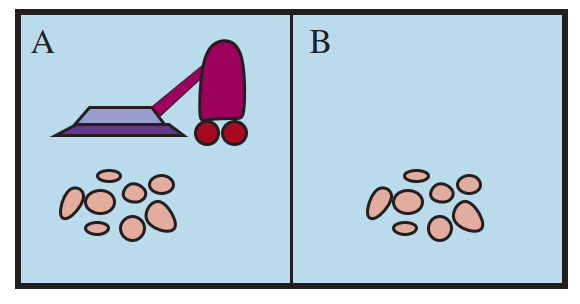
### **What we wll build**
A tiny two-room "vacuum world" environment, then **five agent programs** — one for each classical architecture covered in the lecture:
1. Simple Reflex Agent
2. Model-Based Reflex Agent
3. Goal-Based Agent
4. Utility-Based Agent
5. Learning Agent

By the end we will be able to run all five against the same environment and compare their performance.


## **Agent = Architecture + Program**

An agent perceives its environment through **sensors** and acts through **actuators**. Its behavior is defined by an **agent function** (percept sequence → action), implemented by an **agent program**.


In [1]:
import random
from copy import deepcopy

LOCATIONS = ["A", "B"]

class VacuumEnvironment:
    def __init__(self, dirt_prob=0.5, seed=42):
        rng = random.Random(seed)
        self.status = {loc: ("Dirty" if rng.random() < dirt_prob else "Clean") for loc in LOCATIONS}
        self.agent_location = rng.choice(LOCATIONS)
        self.performance = 0       # scorecard: +10 per successful clean, -1 per move
        self.history = []               # (location, action, world_state) trace for inspection

    def percept(self):
        '''Sensors: the agent perceives only its current location and its status.'''
        return (self.agent_location, self.status[self.agent_location])

    def execute(self, action):
        '''Actuators: apply the chosen action to the environment.'''
        loc = self.agent_location
        if action == "Suck":
            if self.status[loc] == "Dirty":
                self.status[loc] = "Clean"
                self.performance += 10
        elif action == "Left":
            self.agent_location = "A"
            self.performance -= 1
        elif action == "Right":
            self.agent_location = "B"
            self.performance -= 1
        elif action == "NoOp":
            pass
        else:
            raise ValueError(f"Unknown action: {action}")

        self.history.append((loc, action, deepcopy(self.status)))
        return self.percept()

    def is_clean(self):
        return all(v == "Clean" for v in self.status.values())


# Quick sanity check
env = VacuumEnvironment(seed=1)
print("Initial world state:", env.status)
print("Initial percept:", env.percept())


Initial world state: {'A': 'Dirty', 'B': 'Clean'}
Initial percept: ('A', 'Dirty')


## 2. **PEAS in Code**

**PEAS** : Performance, Environment, Actuators, Sensors is a way to precisely specify the task. Let's write it out as a simple spec for our vacuum world.

In [2]:
vacuum_world_peas = {
    "Performance": "Reward for clean squares, small penalty per move",
    "Environment": "Two locations (A, B), each Dirty or Clean",
    "Actuators": "Suck, Left, Right, NoOp",
    "Sensors": "Current location, dirt status of current location",
}

for k, v in vacuum_world_peas.items():
    print(f"{k:12s}: {v}")

Performance : Reward for clean squares, small penalty per move
Environment : Two locations (A, B), each Dirty or Clean
Actuators   : Suck, Left, Right, NoOp
Sensors     : Current location, dirt status of current location


## **3. Agent Architecture 1: Simple Reflex Agent**

Acts only on the **current percept** using condition–action rules. No memory of the past.

In [3]:
def simple_reflex_agent():
    '''Rule: if the current square is dirty, clean it; otherwise move to the other square.'''
    def program(percept):
        location, status = percept
        if status == "Dirty":
            return "Suck"
        elif location == "A":
            return "Right"
        else:
            return "Left"
    return program


In [4]:
def run(agent_program, steps=6, seed=42):
    env = VacuumEnvironment(seed=seed)
    for _ in range(steps):
        p = env.percept()
        a = agent_program(p)
        env.execute(a)
    return env.performance, env.is_clean(), env.history


In [5]:
_, _, trace = run(simple_reflex_agent(), seed=3)
for step, (loc, action, state) in enumerate(trace, 1):
    print(f"Step {step}: at {loc} -> action={action:6s} -> world={state}")


Step 1: at B -> action=Left   -> world={'A': 'Dirty', 'B': 'Clean'}
Step 2: at A -> action=Suck   -> world={'A': 'Clean', 'B': 'Clean'}
Step 3: at A -> action=Right  -> world={'A': 'Clean', 'B': 'Clean'}
Step 4: at B -> action=Left   -> world={'A': 'Clean', 'B': 'Clean'}
Step 5: at A -> action=Right  -> world={'A': 'Clean', 'B': 'Clean'}
Step 6: at B -> action=Left   -> world={'A': 'Clean', 'B': 'Clean'}


## **4. Agent Architecture 2: Model-Based Reflex Agent**

Maintains an **internal state** (a simple model of the world) so it can act sensibly even when it can't see everything at once — here, it remembers what it has already found at each location, and stops once it believes both are clean.

In [6]:
def model_based_reflex_agent():
    model = {"A": None, "B": None}   # internal state: what we believe about each location

    def program(percept):
        location, status = percept
        model[location] = status              # update our internal model with what we just observed
        if status == "Dirty":
            return "Suck"
        if model["A"] == "Clean" and model["B"] == "Clean":
            return "NoOp"                          # we believe the job is done — stop wasting moves
        return "Right" if location == "A" else "Left"
    return program


In [7]:
_, _, trace = run(model_based_reflex_agent(), seed=3)
for step, (loc, action, state) in enumerate(trace, 1):
    print(f"Step {step}: at {loc} -> action={action:6s} -> world={state}")

Step 1: at B -> action=Left   -> world={'A': 'Dirty', 'B': 'Clean'}
Step 2: at A -> action=Suck   -> world={'A': 'Clean', 'B': 'Clean'}
Step 3: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 4: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 5: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 6: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}


## **5. Agent Architecture 3: Goal-Based Agent**

Acts to achieve an explicit **goal** ("both squares clean"), using a small plan rather than a fixed rule.

In [8]:
def goal_based_agent():
    goal_reached_plan = []                # a tiny plan: where to go next once the current square is clean

    def program(percept):
        location, status = percept
        nonlocal goal_reached_plan
        if status == "Dirty":
            return "Suck"                       # always satisfy the immediate sub-goal first
        if not goal_reached_plan:
            move = "Right" if location == "A" else "Left"
            goal_reached_plan = [move]           # plan: go check the other square next
        return goal_reached_plan.pop(0)
    return program


## **6. Agent Architecture 4: Utility-Based Agent**

Instead of a single goal, ranks actions using a **utility function** that trades off multiple concerns — here, cleanliness vs. a simulated battery budget (mirroring the self-driving-car speed/safety/comfort trade-off from the lecture).

In [9]:
def utility_based_agent(battery_start=6):
    battery = {"level": battery_start}

    def utility(action, status, battery_level):
        u = 0
        if action == "Suck" and status == "Dirty":
            u += 10
        if action in ("Left", "Right"):
            u -= 2                                           # moving costs energy
        if battery_level <= 2 and action in ("Left", "Right"):
            u -= 5                                           # heavily discourage moving on low battery
        return u

    def program(percept):
        location, status = percept
        if battery["level"] <= 0:
            return "NoOp"                            # out of battery — must stop
        candidates = ["Suck", "Left", "Right", "NoOp"]
        action = max(candidates, key=lambda a: utility(a, status, battery["level"]))
        if action in ("Left", "Right", "Suck"):
            battery["level"] -= 1
        return action
    return program


## **7. Agent Architecture 5: Learning Agent**

Adds a **learning element**: the agent updates a simple value table from the reward it observes, gradually improving its policy — a toy version of the feedback loop behind RLHF-trained LLMs mentioned on the "Bridge" slide.

In [10]:
def learning_agent():
    q = {}                                  # (state, action) -> learned value
    last = {"state": None, "action": None}

    def program(percept):
        state = percept
        actions = ["Suck", "Left", "Right"]
        for a in actions:
            q.setdefault((state, a), 0.0)

        # Learning element: update the value of the last (state, action) using the reward we just saw
        if last["state"] is not None:
            reward = 10 if state[1] == "Clean" and last["action"] == "Suck" else -1
            key = (last["state"], last["action"])
            q[key] += 0.5 * (reward - q[key])       # simple running-average update

        # Performance element: mostly exploit the best known action, occasionally explore
        if random.random() < 0.1:
            action = random.choice(actions)
        else:
            action = max(actions, key=lambda a: q[(state, a)])

        last["state"], last["action"] = state, action
        return action
    return program


## **8. Run and Compare All Five Agents**

Same environment, same starting seed, six time steps each — this isolates the effect of **architecture** on performance.


In [11]:
def run(agent_program, steps=6, seed=42):
    env = VacuumEnvironment(seed=seed)
    for _ in range(steps):
        p = env.percept()
        a = agent_program(p)
        env.execute(a)
    return env.performance, env.is_clean(), env.history


random.seed(0)  # for reproducibility of the learning agent's exploration
agents = [
    ("Simple Reflex", simple_reflex_agent),
    ("Model-Based Reflex", model_based_reflex_agent),
    ("Goal-Based", goal_based_agent),
    ("Utility-Based", utility_based_agent),
    ("Learning", learning_agent),
]

print(f"{'Architecture':22s}{'Performance':>12s}{'All Clean?':>12s}")
print("-" * 46)
for name, factory in agents:
    perf, clean, _ = run(factory())
    print(f"{name:22s}{perf:12d}{str(clean):>12s}")


Architecture           Performance  All Clean?
----------------------------------------------
Simple Reflex                    5        True
Model-Based Reflex               9        True
Goal-Based                       5        True
Utility-Based                   10        True
Learning                        10        True


## **9. Inspect an Agent's Behavior Trace**

It's often more instructive to *watch* an agent than to just see its final score. Let's trace the Model-Based Reflex Agent step by step.


In [12]:
_, _, trace = run(model_based_reflex_agent())
for step, (loc, action, state) in enumerate(trace, 1):
    print(f"Step {step}: at {loc} -> action={action:6s} -> world={state}")


Step 1: at B -> action=Suck   -> world={'A': 'Clean', 'B': 'Clean'}
Step 2: at B -> action=Left   -> world={'A': 'Clean', 'B': 'Clean'}
Step 3: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 4: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 5: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}
Step 6: at A -> action=NoOp   -> world={'A': 'Clean', 'B': 'Clean'}


## 10. Exercises

Work through these to deepen your understanding before Lecture 2.

1. **Environment properties:** Modify `VacuumEnvironment` so that dirt can randomly reappear after being cleaned (a *stochastic*, non-episodic environment). Which agent architecture do you expect to degrade the least? Test your hypothesis.
2. **Partial observability:** Change the environment so the agent's `percept()` only returns the dirt status, never the location. Which architectures still work? Which break, and why?
3. **Scale it up:** Extend `LOCATIONS` to `["A", "B", "C", "D"]` arranged in a row. Update the agent programs' movement logic accordingly. Does the Simple Reflex Agent still reach `NoOp` sensibly?
4. **New utility function:** In `utility_based_agent`, add a time-pressure term (e.g., a deadline after which `Suck` is worth less). Observe how the agent's choices shift.
Fill in your answers in the cells below.


### Exercise 1 — Answer: stochastic, non-episodic dirt

**Hypothesis:** architectures that *stop* once they believe the job is done should degrade most; the Simple Reflex Agent, which never stops, should degrade least.

**Result:** half right. Simple Reflex and Goal-Based tie at the top (the goal-based agent has no `NoOp` branch, so here it degenerates into the same patrol loop). Model-Based Reflex drops because it trusts a stale belief. Utility-Based drops *furthest* — a bug the original two-square episode never exposed: moving costs −2 while sucking a clean square costs 0, so it parks on one square forever.

**Takeaway:** what degrades is not *having* a model, it is trusting a stale one — or pricing movement without pricing neglect. The fix is to make beliefs expire.

In [13]:
# Exercise 1 — Stochastic, non-episodic dirt
#
# Dirt can reappear after being cleaned, so the world never "ends".
# Hypothesis: the architectures that STOP once they believe the job is done
# (Model-Based, Goal-Based) degrade the most, because their belief goes stale.
# The Simple Reflex Agent, which never stops patrolling, degrades the least.

class StochasticVacuumEnvironment(VacuumEnvironment):
    """Same world, but each Clean square can get dirty again every time step."""

    def __init__(self, dirt_prob=0.5, respawn_prob=0.15, seed=42):
        super().__init__(dirt_prob=dirt_prob, seed=seed)
        self.respawn_prob = respawn_prob
        self.rng = random.Random(seed + 1000)   # separate stream, so respawns don't shift the start state
        self.steps = 0
        self.clean_square_steps = 0             # for measuring "how clean was the world, on average"

    def execute(self, action):
        super().execute(action)
        for loc in LOCATIONS:                                # the environment acts on its own now
            if self.status[loc] == "Clean" and self.rng.random() < self.respawn_prob:
                self.status[loc] = "Dirty"
        self.steps += 1
        self.clean_square_steps += sum(1 for v in self.status.values() if v == "Clean")
        return self.percept()

    def cleanliness(self):
        """Fraction of (square, time step) pairs that were clean. The right metric
        for a non-episodic task: there is no final state to score."""
        return self.clean_square_steps / (self.steps * len(LOCATIONS))


def run_stochastic(agent_program, steps=40, seed=42, respawn_prob=0.15):
    env = StochasticVacuumEnvironment(seed=seed, respawn_prob=respawn_prob)
    for _ in range(steps):
        env.execute(agent_program(env.percept()))
    return env.performance, env.cleanliness()


STEPS, SEEDS = 40, range(8)
stochastic_agents = [
    ("Simple Reflex",      simple_reflex_agent),
    ("Model-Based Reflex", model_based_reflex_agent),
    ("Goal-Based",         goal_based_agent),
    ("Utility-Based",      lambda: utility_based_agent(battery_start=STEPS)),  # battery scaled to the longer run
    ("Learning",           learning_agent),
]

print(f"{'Architecture':22s}{'Avg performance':>17s}{'Avg cleanliness':>17s}")
print("-" * 56)
for name, factory in stochastic_agents:
    results = []
    for s in SEEDS:
        random.seed(0)                       # keep the learning agent's exploration reproducible
        results.append(run_stochastic(factory(), steps=STEPS, seed=s))
    perf = sum(r[0] for r in results) / len(results)
    clean = sum(r[1] for r in results) / len(results)
    print(f"{name:22s}{perf:17.1f}{clean:16.0%}")

print("""
Reading the table:

* Simple Reflex and Goal-Based tie at the top. Neither ever stops: the goal-
  based agent as written has no NoOp branch, so in this world it degenerates
  into the same patrol loop as the reflex agent. Constant re-sensing is
  exactly the right behaviour when dirt keeps coming back.
* Model-Based Reflex drops. It latches onto "both squares are Clean", emits
  NoOp forever, and never looks again - its model is a snapshot of a world
  that has since changed.
* Utility-Based drops furthest. Moving costs -2 while Suck-on-a-clean-square
  costs 0, so it never pays to walk to the other square. It parks on one
  square, cleans that one forever, and lets the other rot.
* Learning does no better: its reward signal only rewards Suck, so it learns
  the same park-and-suck policy.

So the hypothesis was half right. The thing that degrades is not "having a
model" - it is *trusting a stale model* (Model-Based) or *pricing movement
without pricing neglect* (Utility-Based). The fix for the first is to make
beliefs expire:""")


def decaying_model_based_agent(staleness_limit=3):
    """Model-based, but a belief older than `staleness_limit` steps is not trusted."""
    model = {loc: None for loc in LOCATIONS}
    last_seen = {loc: -10**9 for loc in LOCATIONS}
    t = {"step": 0}

    def program(percept):
        location, status = percept
        t["step"] += 1
        model[location] = status
        last_seen[location] = t["step"]
        if status == "Dirty":
            return "Suck"
        believed_clean = all(
            model[loc] == "Clean" and t["step"] - last_seen[loc] <= staleness_limit
            for loc in LOCATIONS
        )
        if believed_clean:
            return "NoOp"
        return "Right" if location == "A" else "Left"
    return program


results = [run_stochastic(decaying_model_based_agent(), steps=STEPS, seed=s) for s in SEEDS]
print(f"\n{'Model-Based + decay':22s}"
      f"{sum(r[0] for r in results)/len(results):17.1f}"
      f"{sum(r[1] for r in results)/len(results):16.0%}")


Architecture            Avg performance  Avg cleanliness
--------------------------------------------------------
Simple Reflex                      93.4             73%
Model-Based Reflex                 67.8             52%
Goal-Based                         93.4             73%
Utility-Based                      58.8             45%
Learning                           58.9             45%

Reading the table:

* Simple Reflex and Goal-Based tie at the top. Neither ever stops: the goal-
  based agent as written has no NoOp branch, so in this world it degenerates
  into the same patrol loop as the reflex agent. Constant re-sensing is
  exactly the right behaviour when dirt keeps coming back.
* Model-Based Reflex drops. It latches onto "both squares are Clean", emits
  NoOp forever, and never looks again - its model is a snapshot of a world
  that has since changed.
* Utility-Based drops furthest. Moving costs -2 while Suck-on-a-clean-square
  costs 0, so it never pays to walk to the oth

### Exercise 2 — Answer: partial observability

`percept()` now returns dirt status only — no location.

* **Fixed-rule Simple Reflex breaks.** With no location it cannot pick a direction, so it commits to one and gets stranded. It fails *silently*: no error, just no progress.
* **Randomised Simple Reflex works,** in expectation. When you cannot sense, randomise.
* **Model-Based works, and works perfectly** — the interesting case. `Left`/`Right` are absolute moves, so one deliberate `Left` tells the agent it is now at A. It **localises itself from its own action history** rather than its sensors.

**Takeaway:** partial observability breaks memoryless agents, and internal state buys the observability back. That is exactly why the model-based box exists in the hierarchy.

In [14]:
# Exercise 2 — Partial observability: the agent can no longer see WHERE it is
#
# percept() now returns only the dirt status of the current square.
# Question: which architectures survive?

class BlindVacuumEnvironment(VacuumEnvironment):
    """Sensors are degraded: dirt status only, no location."""

    def percept(self):
        return self.status[self.agent_location]      # a bare "Dirty"/"Clean", no location


def run_blind(agent_program, steps=6, seed=3):
    env = BlindVacuumEnvironment(seed=seed)
    for _ in range(steps):
        env.execute(agent_program(env.percept()))
    return env.performance, env.is_clean(), env.history


# --- (a) Simple reflex with a fixed rule: BREAKS -------------------------------
def blind_fixed_reflex_agent():
    """No memory, no location. The best it can do is one fixed move direction."""
    def program(status):
        return "Suck" if status == "Dirty" else "Right"
    return program


# --- (b) Simple reflex + randomisation: WORKS, eventually ----------------------
def blind_random_reflex_agent(seed=7):
    """AIMA's answer to unobservable location: randomise the move.
    Still memoryless, but no longer trapped in a corner."""
    rng = random.Random(seed)
    def program(status):
        return "Suck" if status == "Dirty" else rng.choice(["Left", "Right"])
    return program


# --- (c) Model-based: WORKS, and works perfectly -------------------------------
def blind_model_based_agent():
    """Key insight: the ACTUATORS are absolute and deterministic - "Left" always
    lands on A, "Right" always lands on B. So after the agent's first move it
    knows exactly where it is, even though the sensors never tell it.
    Internal state has *reconstructed* the observability the sensors lost."""
    belief = {"location": None, "A": None, "B": None}

    def program(status):
        loc = belief["location"]
        if loc is not None:
            belief[loc] = status                       # we know where this reading came from
        if status == "Dirty":
            if loc is not None:
                belief[loc] = "Clean"                  # Suck will succeed
            return "Suck"
        if loc is None:                                # first clean percept: localise ourselves
            belief["location"] = "A"
            return "Left"                              # "Left" is a teleport-to-A, so this is a self-locate
        if belief["A"] == "Clean" and belief["B"] == "Clean":
            return "NoOp"
        belief["location"] = "B" if loc == "A" else "A"
        return "Right" if loc == "A" else "Left"
    return program


for label, factory in [("(a) fixed reflex  ", blind_fixed_reflex_agent),
                       ("(b) random reflex ", blind_random_reflex_agent),
                       ("(c) model-based   ", blind_model_based_agent)]:
    perf, clean, trace = run_blind(factory())
    actions = " ".join(a for _, a, _ in trace)
    print(f"{label} perf={perf:4d}  all clean={str(clean):5s}  actions: {actions}")

print("""
* (a) Fixed reflex BREAKS. With no location in the percept it cannot choose a
  direction, so it commits to one - "Right" - forever. In this run it starts
  on a clean B and simply re-enters B six times, paying the move penalty each
  step while the dirt in A is never found (perf -6, world never clean). Note
  it does not fail loudly; it just quietly stops making progress.
* (b) Randomised reflex WORKS, in expectation. Still no memory, but a coin flip
  guarantees it visits both squares eventually. This is the classic result:
  when you cannot sense, randomise.
* (c) Model-based WORKS, and cleanly. Because Left/Right are absolute moves,
  one deliberate "Left" tells the agent it is now at A - it has localised
  itself using its own action history rather than its sensors. From there it
  tracks position by dead reckoning and can still emit NoOp when done.

The general rule: partial observability breaks memoryless agents, and internal
state is what buys the observability back. That is precisely why the
model-based box exists in the AIMA hierarchy.""")


(a) fixed reflex   perf=  -6  all clean=False  actions: Right Right Right Right Right Right
(b) random reflex  perf=   5  all clean=True   actions: Right Left Suck Right Left Left
(c) model-based    perf=   8  all clean=True   actions: Left Suck Right NoOp NoOp NoOp

* (a) Fixed reflex BREAKS. With no location in the percept it cannot choose a
  direction, so it commits to one - "Right" - forever. In this run it starts
  on a clean B and simply re-enters B six times, paying the move penalty each
  step while the dirt in A is never found (perf -6, world never clean). Note
  it does not fail loudly; it just quietly stops making progress.
* (b) Randomised reflex WORKS, in expectation. Still no memory, but a coin flip
  guarantees it visits both squares eventually. This is the classic result:
  when you cannot sense, randomise.
* (c) Model-based WORKS, and cleanly. Because Left/Right are absolute moves,
  one deliberate "Left" tells the agent it is now at A - it has localised
  itself usin

### Exercise 3 — Answer: scaling to a row of four

Scaling up forces a semantic change: with two squares `Left`/`Right` could be *absolute* (teleport to A / to B); in a row they must be *relative* one-step moves.

**Does the Simple Reflex Agent still reach `NoOp` sensibly? No — and worse.** The naive rule ("Left at the right wall, else Right") turns the wall into a **2-cycle**: it oscillates between the last two squares instead of patrolling. Direction of travel is *state*, and a memoryless agent has nowhere to keep it. At n=4 it gets away with this; at n=8 it strands itself while dirt sits behind it.

And `NoOp` is unreachable for a second, independent reason: `NoOp` is only rational once *every* square is clean — a fact about squares you are not standing on.

**Takeaway:** randomising escapes the oscillation trap, but a random walk's cover time grows like n², so it is survivable, not free.

In [15]:
# Exercise 3 — Scale up to a row of four squares: A - B - C - D
#
# Note the change of semantics: with two squares "Left"/"Right" could be
# absolute (teleport to A / teleport to B). In a row of four they must become
# RELATIVE moves, which is what makes the exercise interesting.

ROW = ["A", "B", "C", "D"]


class RowVacuumEnvironment:
    """Same PEAS, but n squares in a row and Left/Right are one step, clamped at the ends."""

    def __init__(self, locations=ROW, dirt_prob=0.5, seed=42):
        rng = random.Random(seed)
        self.locations = list(locations)
        self.status = {loc: ("Dirty" if rng.random() < dirt_prob else "Clean") for loc in self.locations}
        self.index = rng.randrange(len(self.locations))
        self.performance = 0
        self.history = []

    @property
    def agent_location(self):
        return self.locations[self.index]

    def percept(self):
        return (self.agent_location, self.status[self.agent_location])

    def execute(self, action):
        loc = self.agent_location
        if action == "Suck":
            if self.status[loc] == "Dirty":
                self.status[loc] = "Clean"
                self.performance += 10
        elif action == "Left":
            self.index = max(0, self.index - 1)          # clamp: bumping into the wall still costs a move
            self.performance -= 1
        elif action == "Right":
            self.index = min(len(self.locations) - 1, self.index + 1)
            self.performance -= 1
        elif action == "NoOp":
            pass
        else:
            raise ValueError(f"Unknown action: {action}")
        self.history.append((loc, action, dict(self.status)))
        return self.percept()

    def is_clean(self):
        return all(v == "Clean" for v in self.status.values())


def run_row(agent_program, steps=14, seed=42):
    env = RowVacuumEnvironment(seed=seed)
    for _ in range(steps):
        env.execute(agent_program(env.percept()))
    return env.performance, env.is_clean(), env.history


def row_simple_reflex_agent(locations=ROW):
    """Memoryless. The only thing it can key off is (location, status), so the
    best fixed rule is: sweep right, and at the right wall sweep left."""
    def program(percept):
        location, status = percept
        if status == "Dirty":
            return "Suck"
        return "Left" if location == locations[-1] else "Right"
    return program


def row_model_based_agent(locations=ROW):
    """Internal state: what we have seen at every square. Sweep right to the wall,
    then left, and stop once all four are believed clean."""
    model = {loc: None for loc in locations}
    direction = {"d": "Right"}

    def program(percept):
        location, status = percept
        model[location] = status
        if status == "Dirty":
            model[location] = "Clean"
            return "Suck"
        if all(v == "Clean" for v in model.values()):
            return "NoOp"                                  # every square seen, every square clean
        if location == locations[-1]:
            direction["d"] = "Left"
        elif location == locations[0]:
            direction["d"] = "Right"
        return direction["d"]
    return program


for label, factory in [("Simple Reflex     ", row_simple_reflex_agent),
                       ("Model-Based Reflex", row_model_based_agent)]:
    perf, clean, trace = run_row(factory())
    actions = " ".join(a for _, a, _ in trace)
    print(f"{label}  perf={perf:4d}  all clean={str(clean):5s}")
    print(f"{'':20s}actions: {actions}")

print("""
Does the Simple Reflex Agent still reach NoOp sensibly? No - and it is worse
than that. Look at its action trace: after cleaning its way right it settles
into "Left Right Left Right ..." - it is not patrolling the row, it is stuck
oscillating between the last two squares.

Why: the rule "Left at the right wall, otherwise Right" makes the right wall a
2-cycle. Direction of travel is *state*, and a memoryless agent has nowhere to
keep it, so it cannot commit to a leftward sweep. With n=4 it gets away with
this, because it cleaned A-D on the way out. With n=8 it does not - it strands
itself at the far end while dirt sits behind it:""")

for n in (2, 4, 8):
    locations = [chr(ord("A") + i) for i in range(n)]
    for label, factory in [("Simple Reflex", row_simple_reflex_agent),
                           ("Model-Based ", row_model_based_agent)]:
        env = RowVacuumEnvironment(locations=locations, seed=42)
        program = factory(locations)
        for _ in range(4 * n):
            env.execute(program(env.percept()))
        print(f"  n={n}  {label}  perf={env.performance:4d}  clean={env.is_clean()}")

print("""
And NoOp is out of reach for a second, independent reason: NoOp is only
rational once you know *every* square is clean, and "every square" is a fact
about squares you are not standing on. A memoryless agent has no place to put
that fact, so its rule set cannot even express the NoOp condition. The
model-based agent keeps both pieces of state - direction of travel and what it
has seen where - so it sweeps properly and then stops.

Exercise 2's lesson applies here too: if you must stay memoryless, randomise.""")


def row_random_reflex_agent(locations=ROW, seed=7):
    """Memoryless, but breaks the oscillation trap with a coin flip."""
    rng = random.Random(seed)
    def program(percept):
        _, status = percept
        return "Suck" if status == "Dirty" else rng.choice(["Left", "Right"])
    return program


for n in (4, 8):
    locations = [chr(ord("A") + i) for i in range(n)]
    cleaned, perfs = 0, []
    for trial in range(20):
        env = RowVacuumEnvironment(locations=locations, seed=42)
        program = row_random_reflex_agent(locations, seed=trial)
        for _ in range(4 * n):
            env.execute(program(env.percept()))
        cleaned += env.is_clean()
        perfs.append(env.performance)
    print(f"  n={n}  Random Reflex over {4*n} steps: cleaned the row in "
          f"{cleaned}/20 trials, avg perf {sum(perfs)/len(perfs):.1f}")

print("""
Randomising escapes the trap but is slow: a random walk's cover time grows
like n-squared, so within a fixed step budget it often has not visited
everything yet. Memorylessness is survivable, not free - which is the point of
the exercise.""")


Simple Reflex       perf=  19  all clean=True 
                    actions: Right Suck Right Suck Right Suck Left Right Left Right Left Right Left Right
Model-Based Reflex  perf=  27  all clean=True 
                    actions: Right Suck Right Suck Right Suck NoOp NoOp NoOp NoOp NoOp NoOp NoOp NoOp

Does the Simple Reflex Agent still reach NoOp sensibly? No - and it is worse
than that. Look at its action trace: after cleaning its way right it settles
into "Left Right Left Right ..." - it is not patrolling the row, it is stuck
oscillating between the last two squares.

Why: the rule "Left at the right wall, otherwise Right" makes the right wall a
2-cycle. Direction of travel is *state*, and a memoryless agent has nowhere to
keep it, so it cannot commit to a leftward sweep. With n=4 it gets away with
this, because it cleaned A-D on the way out. With n=8 it does not - it strands
itself at the far end while dirt sits behind it:
  n=2  Simple Reflex  perf=   3  clean=True
  n=2  Model-Bas

### Exercise 4 — Answer: a time-pressure term

Three changes to `utility_based_agent`: a **deadline** term (clean squares decay in value once the shift is ending), a **one-step lookahead** so moving can be worth something (fixing the parking bug Exercise 1 found), and a **decaying belief** so a square cleaned long ago looks suspicious again.

**How the choices shift:** early on, a trip is worth ≈ `p_dirty × 10` against a −2 travel cost, so the agent patrols. Past the deadline `time_factor` shrinks that payoff geometrically while travel stays at −2, so the move term crosses below `NoOp`'s flat 0 and it stops travelling — then later even sucking dirt falls below 0 and it stops cleaning. You can watch `Suck` decay `+10 → +2.2 → +0.3` in the trace.

**Takeaway:** nobody wrote "if late, stop cleaning" — the behaviour falls out of arithmetic between competing terms. That is the power of utility agents, and also why they are the hardest to debug.

In [16]:
# Exercise 4 — Add time pressure to the utility function
#
# Three changes to `utility_based_agent`:
#   1. A DEADLINE term: a clean square is worth full value up to the deadline
#      and decays afterwards ("the shift is ending, cleaning matters less").
#   2. A one-step LOOKAHEAD, so moving can be worth something. In the original,
#      moving scored a flat -2 while Suck-on-a-clean-square scored 0, so the
#      agent could never justify walking anywhere - the parking bug Exercise 1
#      exposed.
#   3. A DECAYING BELIEF, so a square we cleaned long ago looks suspicious
#      again - Exercise 1's staleness fix, expressed as a probability instead
#      of a hard cutoff.
#
# Runs in Exercise 1's StochasticVacuumEnvironment, so run that cell first.

def utility_agent_with_deadline(battery_start=6, deadline=4, decay=0.6,
                                respawn_belief=0.15, verbose=False):
    state = {"battery": battery_start, "t": 0}
    belief = {loc: "Unknown" for loc in LOCATIONS}
    last_seen = {loc: 0 for loc in LOCATIONS}

    def time_factor(t):
        """What a clean square is worth at time t: full value up to the deadline, then decaying."""
        return 1.0 if t <= deadline else decay ** (t - deadline)

    def p_dirty(dest, t):
        """How likely is the square over there to be dirty, given what we last saw?"""
        if belief[dest] == "Dirty":
            return 1.0
        if belief[dest] == "Unknown":
            return 0.5
        age = t - last_seen[dest]                             # the longer ago we looked, the less we know
        return 1 - (1 - respawn_belief) ** age

    def utility(action, location, status, t, battery):
        if action == "Suck":
            return 10 * time_factor(t) if status == "Dirty" else -0.5   # sucking a clean square wastes an actuation
        if action in ("Left", "Right"):
            dest = "A" if action == "Left" else "B"
            if dest == location:
                return -5.0                                   # a move that goes nowhere
            u = p_dirty(dest, t) * 10 * time_factor(t + 1) - 2
            if battery <= 2:
                u -= 5                                        # hoard energy when nearly flat
            return u
        return 0.0                                            # NoOp: the do-nothing baseline

    def program(percept):
        location, status = percept
        state["t"] += 1
        belief[location] = status
        last_seen[location] = state["t"]
        if state["battery"] <= 0:
            return "NoOp"
        scores = {a: utility(a, location, status, state["t"], state["battery"])
                  for a in ("Suck", "Left", "Right", "NoOp")}
        action = max(scores, key=scores.get)
        if verbose:
            pretty = "  ".join(f"{a}={scores[a]:+6.1f}" for a in ("Suck", "Left", "Right", "NoOp"))
            flag = "" if state["t"] <= deadline else "  (past deadline)"
            print(f"  t={state['t']:2d} at {location} ({status:5s})  {pretty}  -> {action}{flag}")
        if action == "Suck":
            belief[location] = "Clean"
        if action in ("Left", "Right", "Suck"):
            state["battery"] -= 1
        return action
    return program


STEPS = 18
print(f"One run, deadline=6 — watch the agent give up as the clock runs out:\n")
env = StochasticVacuumEnvironment(seed=5, respawn_prob=0.15)
program = utility_agent_with_deadline(battery_start=STEPS, deadline=6, verbose=True)
for _ in range(STEPS):
    env.execute(program(env.percept()))
print(f"\n  -> performance={env.performance}, cleanliness={env.cleanliness():.0%}\n")

print(f"{'deadline':>10s}{'avg performance':>18s}{'avg cleanliness':>18s}")
print("-" * 46)
for deadline in (STEPS, 14, 12, 10, 8, 6, 4, 2, 0):
    results = []
    for s in range(60):
        env = StochasticVacuumEnvironment(seed=s, respawn_prob=0.15)
        program = utility_agent_with_deadline(battery_start=STEPS, deadline=deadline)
        for _ in range(STEPS):
            env.execute(program(env.percept()))
        results.append((env.performance, env.cleanliness()))
    print(f"{deadline:>10d}{sum(r[0] for r in results)/len(results):>18.1f}"
          f"{sum(r[1] for r in results)/len(results):>17.0%}")

print("""
How the choices shift: early in the run a trip to the other square is worth
roughly p_dirty x 10 minus the -2 travel cost, so the agent patrols and cleans.
Once t passes the deadline, time_factor shrinks that payoff geometrically while
the travel cost stays at -2. The move term crosses below NoOp's flat 0 and the
agent stops travelling; a little later even Suck-on-dirt falls under 0 and it
stops cleaning altogether. Tighten the deadline and that crossover simply
happens sooner, so the table slides down gradually instead of flipping at one
value - cleanliness falls monotonically from 76% to 50%, and performance
tracks it (the 6-vs-4 blip is seed noise, not a real reversal).

That is what makes utility agents worth the extra machinery: nobody wrote
"if late, stop cleaning". The behaviour falls out of arithmetic between
competing terms. It is also why they are the hardest to debug - Exercise 1's
failure (parking on one square forever) was not a broken rule, it was two
terms priced wrong.""")


One run, deadline=6 — watch the agent give up as the clock runs out:

  t= 1 at A (Clean)  Suck=  -0.5  Left=  -5.0  Right=  +3.0  NoOp=  +0.0  -> Right
  t= 2 at B (Clean)  Suck=  -0.5  Left=  -0.5  Right=  -5.0  NoOp=  +0.0  -> NoOp
  t= 3 at B (Clean)  Suck=  -0.5  Left=  +0.8  Right=  -5.0  NoOp=  +0.0  -> Left
  t= 4 at A (Clean)  Suck=  -0.5  Left=  -5.0  Right=  -0.5  NoOp=  +0.0  -> NoOp
  t= 5 at A (Clean)  Suck=  -0.5  Left=  -5.0  Right=  +0.8  NoOp=  +0.0  -> Right
  t= 6 at B (Clean)  Suck=  -0.5  Left=  -1.1  Right=  -5.0  NoOp=  +0.0  -> NoOp
  t= 7 at B (Clean)  Suck=  -0.5  Left=  -1.0  Right=  -5.0  NoOp=  +0.0  -> NoOp  (past deadline)
  t= 8 at B (Clean)  Suck=  -0.5  Left=  -1.2  Right=  -5.0  NoOp=  +0.0  -> NoOp  (past deadline)
  t= 9 at B (Dirty)  Suck=  +2.2  Left=  -1.4  Right=  -5.0  NoOp=  +0.0  -> Suck  (past deadline)
  t=10 at B (Clean)  Suck=  -0.5  Left=  -1.6  Right=  -5.0  NoOp=  +0.0  -> NoOp  (past deadline)
  t=11 at B (Clean)  Suck=  -0.5  Left= 

        12              40.8              71%


        10              38.2              67%
         8              36.1              64%


         6              34.6              61%
         4              34.8              60%
         2              33.7              57%


         0              29.0              50%

How the choices shift: early in the run a trip to the other square is worth
roughly p_dirty x 10 minus the -2 travel cost, so the agent patrols and cleans.
Once t passes the deadline, time_factor shrinks that payoff geometrically while
the travel cost stays at -2. The move term crosses below NoOp's flat 0 and the
agent stops travelling; a little later even Suck-on-dirt falls under 0 and it
stops cleaning altogether. Tighten the deadline and that crossover simply
happens sooner, so the table slides down gradually instead of flipping at one
value - cleanliness falls monotonically from 76% to 50%, and performance
tracks it (the 6-vs-4 blip is seed noise, not a real reversal).

That is what makes utility agents worth the extra machinery: nobody wrote
"if late, stop cleaning". The behaviour falls out of arithmetic between
competing terms. It is also why they are the hardest to debug - Exercise 1's
failure (parking on one square forever) was not

---

## 11. Where this lands

Across four exercises the same pattern keeps showing up: **an architecture is not
better or worse in the abstract — it is better or worse for an environment.**

| Environment property | What it breaks | What it rewards |
|---|---|---|
| Dirt reappears (non-episodic) | Beliefs that never expire | Re-sensing, or beliefs with a decay policy |
| Location not observable | Memoryless rules | Internal state (or randomisation as a cheap substitute) |
| More than two squares | Fixed direction rules (oscillation trap) | State for *direction*, not just *contents* |
| A deadline | Fixed goals | A utility function that can trade goals off |

Notice that each exercise found a bug that the original six-step, two-square,
fully-observable episode could not surface. The agents did not change; the
environment got honest. That is the practical lesson worth carrying into
Lecture 2 — **most agent failures are environment assumptions that stopped
holding**, and this is exactly why real agent work is dominated by evaluation
rather than by architecture.